<a href="https://colab.research.google.com/github/sadumina/Deep-Learning-Assignment-Group-ID-5/blob/model%2FClassic-CNN/CNN-Apitos2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kaggle
# upload kaggle.json API token first
!kaggle competitions download -c aptos2019-blindness-detection
!unzip aptos2019-blindness-detection.zip -d data/

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
unzip:  cannot find or open aptos2019-blindness-detection.zip, aptos2019-blindness-detection.zip.zip or aptos2019-blindness-detection.zip.ZIP.


In [3]:
# Upload kaggle.json
from google.colab import files
files.upload()  # select kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [4]:
!pip install -q kaggle
!kaggle competitions download -c aptos2019-blindness-detection
!unzip -q aptos2019-blindness-detection.zip -d data/

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles
unzip:  cannot find or open aptos2019-blindness-detection.zip, aptos2019-blindness-detection.zip.zip or aptos2019-blindness-detection.zip.ZIP.


In [5]:
!kaggle competitions download -c aptos2019-blindness-detection

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [6]:
!kaggle competitions list -s aptos

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/ListCompetitions


In [8]:
!mkdir -p ~/.kaggle
!echo "KGAT_0626eeea9f69c38ea043760f1d09d936" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [9]:
!rm -f ~/.kaggle/kaggle.json

In [10]:
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [13]:
!kaggle competitions download -c aptos2019-blindness-detection
!unzip -q aptos2019-blindness-detection.zip -d /content/data/

100% 9.51G/9.51G [04:17<00:00, 39.7MB/s]



In [15]:
!rm -rf /content/data

In [16]:
!unzip -q -o aptos2019-blindness-detection.zip -d /content/data/

In [17]:
import os
print(os.listdir('/content/data/'))

import pandas as pd
train_df = pd.read_csv('/content/data/train.csv')
print(train_df.shape)

['train.csv', 'train_images', 'sample_submission.csv', 'test_images', 'test.csv']
(3662, 2)


In [18]:
import os
import pandas as pd

data_dir = '/content/data'
train_df = pd.read_csv(f'{data_dir}/train.csv')
print(train_df.shape)
print(train_df.head())
print(train_df['diagnosis'].value_counts().sort_index())

(3662, 2)
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(img_path, target_size=224):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)
    img = img[y:y+h, x:x+w]

    img = cv2.resize(img, (target_size, target_size))

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img = cv2.merge((l, a, b))
    img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)

    return img

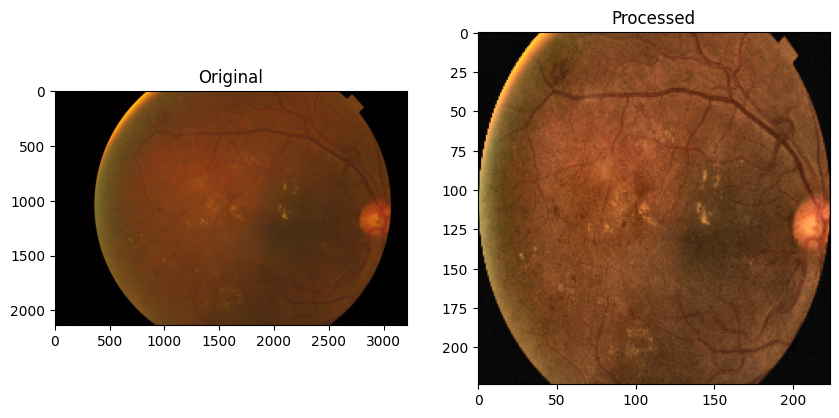

In [20]:
sample_id = train_df.iloc[0]['id_code']
sample_path = f"{data_dir}/train_images/{sample_id}.png"

processed = preprocess_image(sample_path)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[1].imshow(processed)
ax[1].set_title("Processed")
plt.show()

In [21]:
from google.colab import drive
drive.mount('/content/drive')

output_dir = '/content/drive/MyDrive/dr_project/processed_images'
os.makedirs(output_dir, exist_ok=True)

for idx, row in train_df.iterrows():
    img_path = f"{data_dir}/train_images/{row['id_code']}.png"
    out_path = f"{output_dir}/{row['id_code']}.png"
    if not os.path.exists(out_path):
        try:
            img = preprocess_image(img_path)
            cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        except Exception as e:
            print(f"Failed on {row['id_code']}: {e}")
    if idx % 500 == 0:
        print(f"Processed {idx}/{len(train_df)}")

Mounted at /content/drive
Processed 0/3662
Processed 500/3662
Processed 1000/3662
Processed 1500/3662
Processed 2000/3662
Processed 2500/3662
Processed 3000/3662
Processed 3500/3662


In [22]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df, test_size=0.2, stratify=train_df['diagnosis'], random_state=42
)
print(f"Train: {len(train_split)}, Val: {len(val_split)}")

train_split.to_csv('/content/drive/MyDrive/dr_project/train_split.csv', index=False)
val_split.to_csv('/content/drive/MyDrive/dr_project/val_split.csv', index=False)

Train: 2929, Val: 733


In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = f"{self.img_dir}/{row['id_code']}.png"
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        label = row['diagnosis']
        if self.transform:
            img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = DRDataset(train_split, output_dir, transform=transform)
val_dataset = DRDataset(val_split, output_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DR_CNN(nn.Module):
    def __init__(self, num_classes=5):
        super(DR_CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # After 4 pools on 224x224 input: 224 -> 112 -> 56 -> 28 -> 14
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DR_CNN(num_classes=5).to(device)
print(model)

DR_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=5, bias=True)
)


In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_split['diagnosis']),
    y=train_split['diagnosis']
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(class_weights)

tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822], device='cuda:0')


In [32]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [28]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import copy

num_epochs = 25
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_labels, train_preds)

    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), '/content/drive/MyDrive/dr_project/best_cnn_model.pth')

Epoch 1/25 | Train Loss: 1.3233 | Train Acc: 0.5145 | Val Loss: 1.3047 | Val Acc: 0.5675 | Val F1: 0.5482
Epoch 2/25 | Train Loss: 1.3242 | Train Acc: 0.5534 | Val Loss: 1.2903 | Val Acc: 0.5102 | Val F1: 0.5051
Epoch 3/25 | Train Loss: 1.3220 | Train Acc: 0.5459 | Val Loss: 1.3153 | Val Acc: 0.5225 | Val F1: 0.5090
Epoch 4/25 | Train Loss: 1.3196 | Train Acc: 0.5807 | Val Loss: 1.3238 | Val Acc: 0.5348 | Val F1: 0.5307
Epoch 5/25 | Train Loss: 1.3154 | Train Acc: 0.5599 | Val Loss: 1.2837 | Val Acc: 0.5553 | Val F1: 0.5442
Epoch 6/25 | Train Loss: 1.2791 | Train Acc: 0.5698 | Val Loss: 1.3553 | Val Acc: 0.5034 | Val F1: 0.5325
Epoch 7/25 | Train Loss: 1.2655 | Train Acc: 0.5804 | Val Loss: 1.2737 | Val Acc: 0.5498 | Val F1: 0.5638
Epoch 8/25 | Train Loss: 1.2345 | Train Acc: 0.6118 | Val Loss: 1.2879 | Val Acc: 0.5689 | Val F1: 0.5926
Epoch 9/25 | Train Loss: 1.2706 | Train Acc: 0.5927 | Val Loss: 1.3104 | Val Acc: 0.5225 | Val F1: 0.5430
Epoch 10/25 | Train Loss: 1.2642 | Train Acc: 

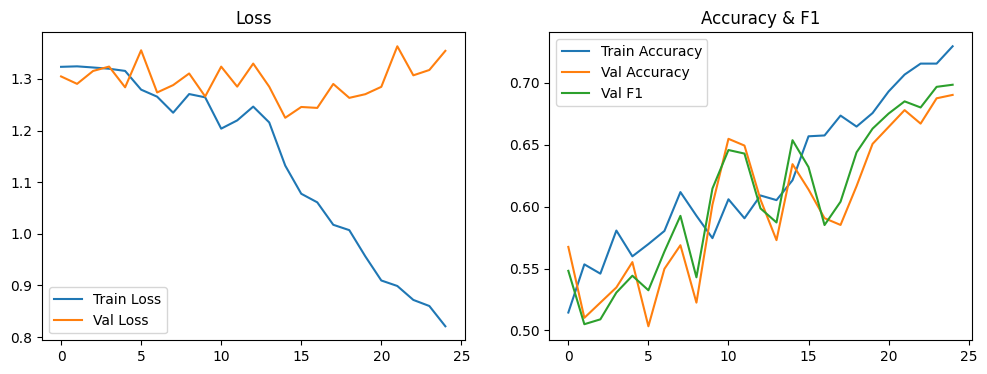

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train_loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Loss')
ax[0].legend()

ax[1].plot(history['train_acc'], label='Train Accuracy')
ax[1].plot(history['val_acc'], label='Val Accuracy')
ax[1].plot(history['val_f1'], label='Val F1')
ax[1].set_title('Accuracy & F1')
ax[1].legend()
plt.show()

In [30]:
from torch.utils.data import WeightedRandomSampler

class_counts = train_split['diagnosis'].value_counts().sort_index().values
sample_weights = [1.0 / class_counts[label] for label in train_split['diagnosis']]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)  # no shuffle= when using a sampler
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)